--- 1. Loading Prepared Data ---
Prepared features dataset loaded successfully.
Dataset dimensions: (134, 33)
Time period: 1991-07-01 00:00:00 to 2024-10-01 00:00:00

First 5 rows of the feature data:
            House_Index_diff1  CPI_diff1  Poverty_Rate_diff1  \
Date                                                           
1991-07-01              -0.81       0.80               0.150   
1991-10-01               1.60       2.05               0.150   
1992-01-01               0.31      -0.05               0.150   
1992-04-01              -0.82       0.20               0.075   
1992-07-01               0.82       1.70               0.075   

            Unemployment_Rate  Median_Household_Income_diff1  \
Date                                                           
1991-07-01                4.5                         -200.0   
1991-10-01                4.6                         -200.0   
1992-01-01                5.3                         -200.0   
1992-04-01                4.8 

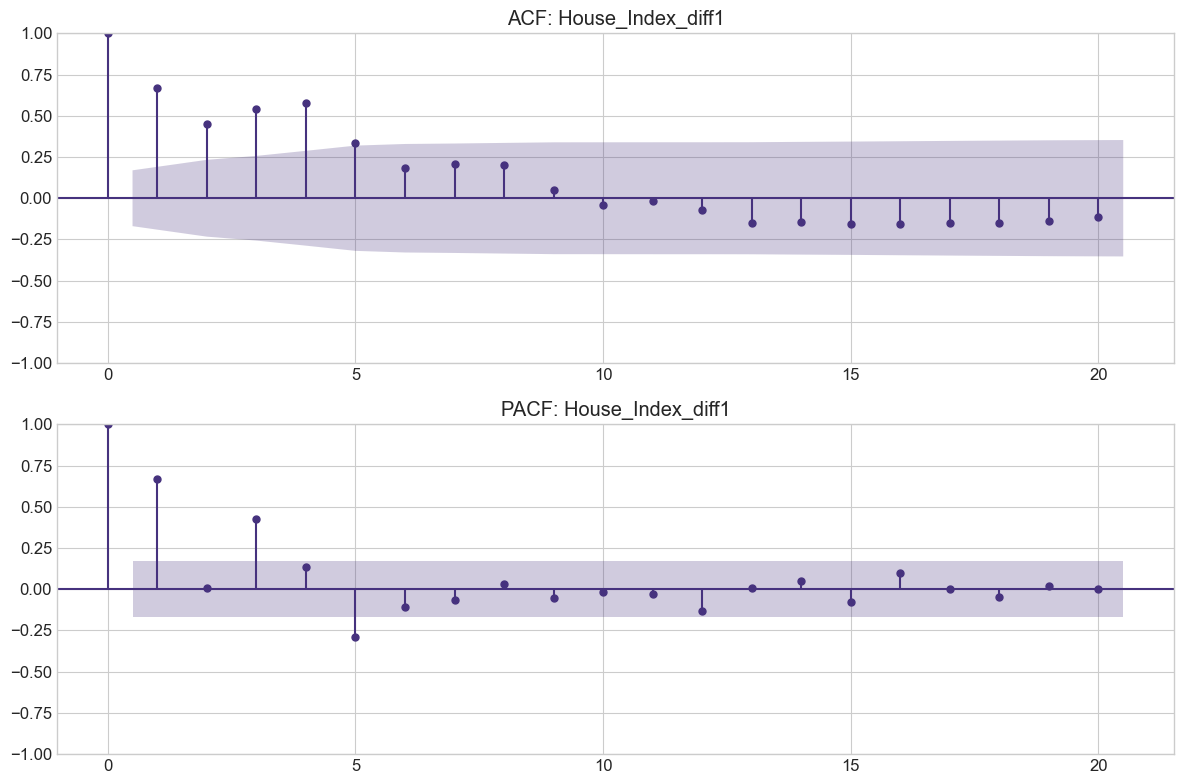

Using ARIMA order based on previous analysis: p=3, d=0, q=1

Evaluating ARIMA(3,0,1) using TimeSeriesSplit:

Fold 1/5: Train size=24, Test size=22
Fold 1 - Test RMSE: 2.8655, MAE: 2.4590, MAPE: 98.62%, R2: -2.7838, DirAcc: 90.91%

Fold 2/5: Train size=46, Test size=22
Fold 2 - Test RMSE: 7.9071, MAE: 6.2199, MAPE: 87.96%, R2: 0.0387, DirAcc: 72.73%

Fold 3/5: Train size=68, Test size=22
Fold 3 - Test RMSE: 8.9008, MAE: 8.4178, MAPE: 1036.74%, R2: -4.2006, DirAcc: 45.45%

Fold 4/5: Train size=90, Test size=22
Fold 4 - Test RMSE: 1.8747, MAE: 1.3850, MAPE: 127.33%, R2: -0.0919, DirAcc: 90.91%

Fold 5/5: Train size=112, Test size=22
Fold 5 - Test RMSE: 6.3886, MAE: 4.6765, MAPE: 78.93%, R2: -0.2873, DirAcc: 81.82%

ARIMA Cross-Validation Summary:
  Average RMSE: 5.5874 (+/- 2.7639)
  Average MAE:  4.6316 (+/- 2.5346)
  Average MAPE: 285.92% (+/- 375.76%)
  Average R2:   -1.4650 (+/- 1.7180)
  Average DirAcc:76.36% (+/- 16.86%)

Residual Analysis (based on last CV fold):


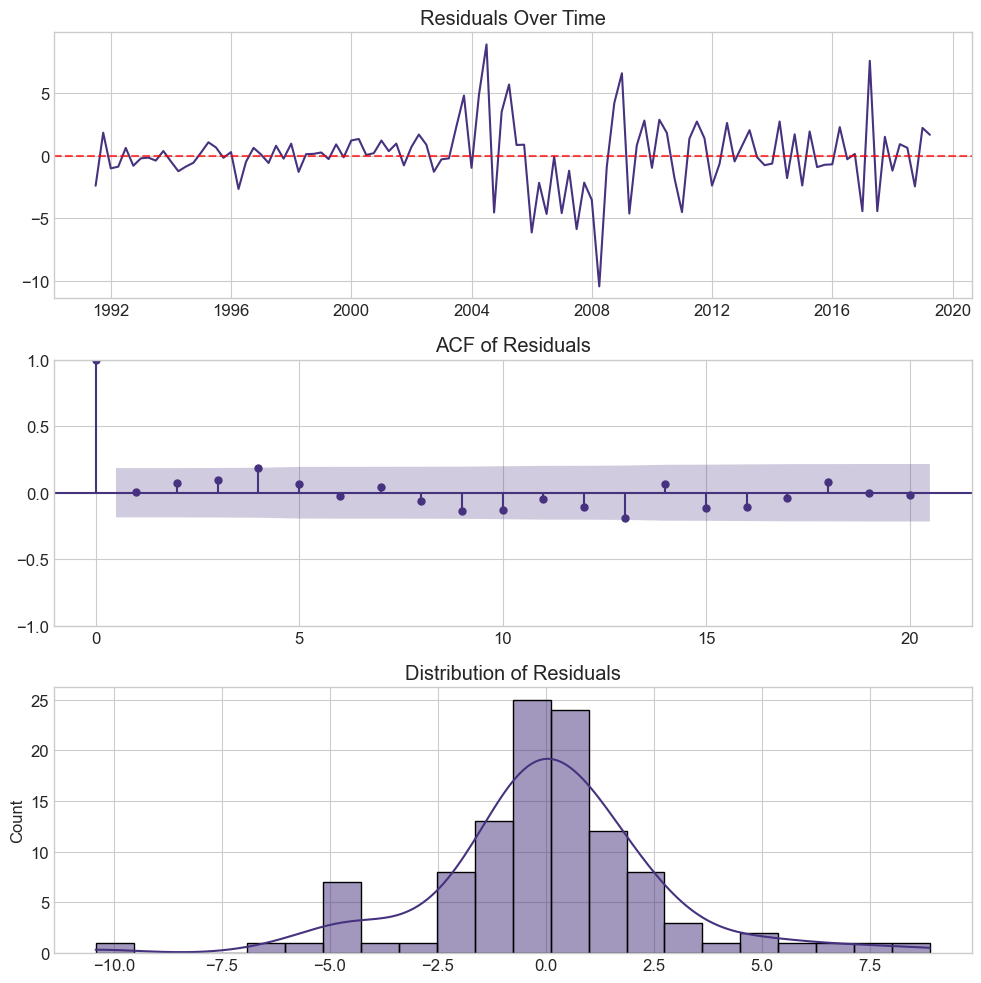


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
10  11.425119    0.32537
Residuals appear uncorrelated (Ljung-Box p >= 0.05).

--- 5. Model Building: VECM ---
Original level data reloaded for VECM.
VECM Exogenous (Stationary) Variables Selected: ['Unemployment_Rate', 'Recession']
VECM Endogenous (Level) Variables: ['House_Index', 'Median_Household_Income', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'GDP']
Note: Manually setting VECM lag order k_ar_diff = 2 for evaluation.
Using Cointegration Rank (r): 1
Using Lag Order (k_ar_diff): 2

Evaluating VECM(k_ar_diff=2, coint_rank=1) using TimeSeriesSplit:
Data aligned for VECM fitting. Shape Levels: (134, 6), Shape Exog: (134, 2)

Fold 1/5: Train size=24, Test size=22
Fold 1 - Error fitting/forecasting VECM: Singular matrix

Fold 2/5: Train size=46, Test size=22
Fold 2 - Error fitting/forecasting VECM: VECMResults.predict() got an unexpected keyword argument 'exog'

Fold 3/5: Train size=68, Test size=22
Fold 3 - Error fitting/forecastin

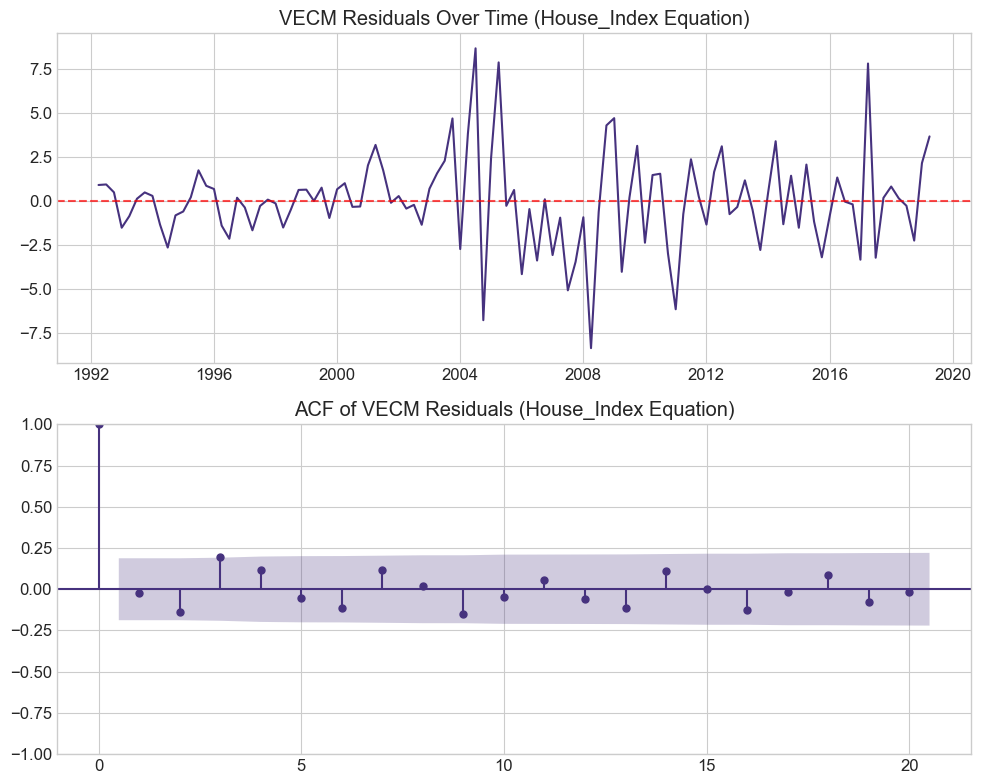


Ljung-Box Test on VECM Residuals (House_Index Equation):
      lb_stat  lb_pvalue
10  14.803989   0.139373
VECM Residuals appear uncorrelated (Ljung-Box p >= 0.05).

--- 6. Model Building: Machine Learning Models - Refined ---

Evaluating Tuned ML Models using GridSearchCV/RandomizedSearchCV with TimeSeriesSplit:

--- Tuning and Evaluating: Ridge_LassoSelect ---
Using GridSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters found for Ridge_LassoSelect:
{'ridge__alpha': 0.01, 'selector__estimator__alpha': 0.2}
Ridge_LassoSelect Best CV RMSE: 1.6942
Ridge_LassoSelect Corresponding CV MAE: 1.3393
Ridge_LassoSelect Corresponding CV R2: 0.1068
Ridge_LassoSelect Corresponding CV DirAcc: 87.27%

--- Tuning and Evaluating: ElasticNet_LassoSelect ---
Using RandomizedSearchCV (n_iter=30)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters found for ElasticNet_LassoSelect:
{'selector__estimator__alpha': 0.2, 'elasticnet__l1_rati

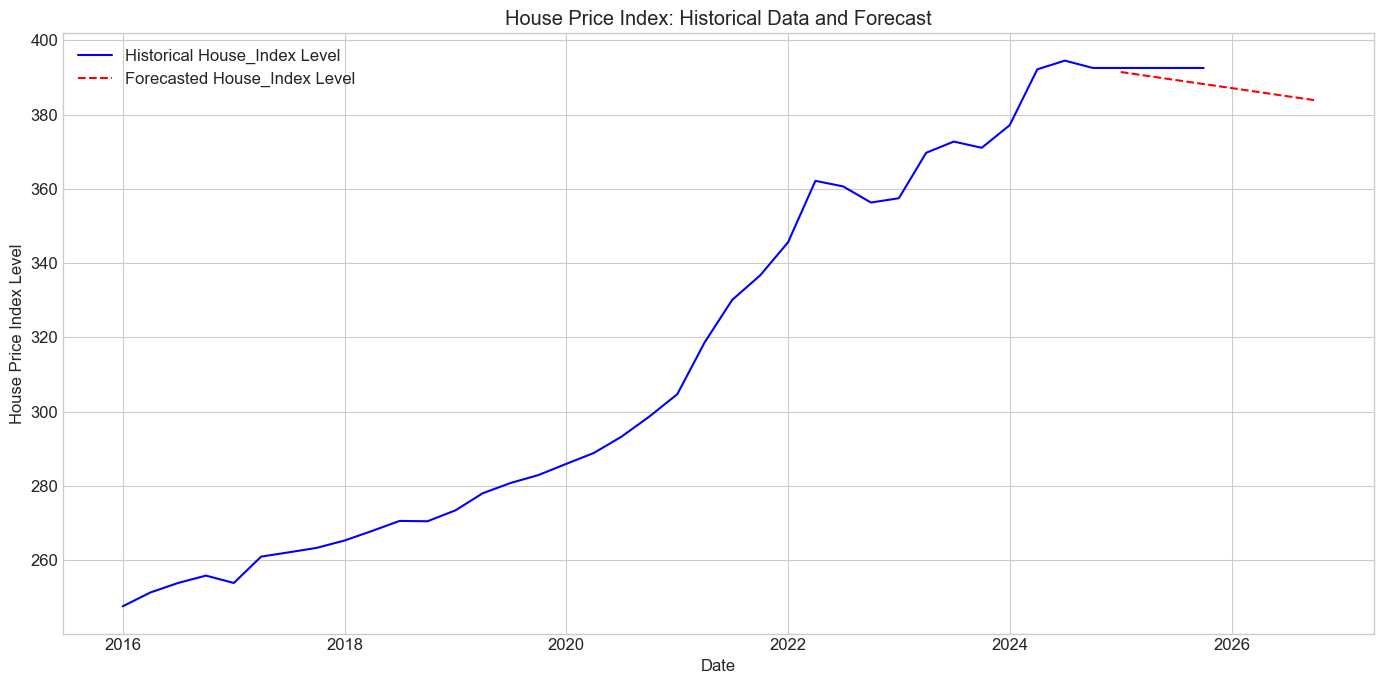


Modeling phase complete.


In [21]:
# -*- coding: utf-8 -*-
"""
DC Housing Market Forecasting - Modeling Phase (Expanded)

Goal: Build, evaluate, and compare time series models (ARIMA, VECM, ML)
      to forecast the DC housing market index based on the prepared data
      from the EDA phase. Use rigorous cross-validation and evaluation.
      Includes additional models and metrics.

Update v2: Corrected handling of variables with conflicting stationarity tests.
Update v3: Added structure for feature selection and hyperparameter tuning for ML models.
           Added notes on VECM troubleshooting.
Update v4: Corrected forecast index generation in Section 8c to use quarterly frequency.
Update v5: Added R2, Directional Accuracy metrics. Added ElasticNet, XGBoost models. Added AutoARIMA section.
"""

# %% 0. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling Libraries
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX # For SARIMA if needed
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, select_coint_rank
from statsmodels.tsa.stattools import adfuller # Re-check stationarity if needed
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
# AutoARIMA
try:
    import pmdarima as pm
    pmdarima_installed = True
except ImportError:
    print("Warning: pmdarima library not found. Install it (`pip install pmdarima`) to use AutoARIMA.")
    pmdarima_installed = False


# Scikit-learn for ML models, metrics, and CV
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet # Added ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer, mean_absolute_percentage_error, r2_score # Added r2_score
# Feature Selection
from sklearn.feature_selection import SelectFromModel, RFE, SelectKBest, f_regression
from sklearn.pipeline import Pipeline
# XGBoost
try:
    import xgboost as xgb
    xgboost_installed = True
except ImportError:
    print("Warning: xgboost library not found. Install it (`pip install xgboost`) to use XGBoost model.")
    xgboost_installed = False


import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# %% 1. Load Prepared Data
# =======================
print("--- 1. Loading Prepared Data ---")
try:
    # Load the features dataset created by the *corrected* EDA script (v3)
    df_features = pd.read_csv('dc_housing_features_ready.csv', index_col='Date', parse_dates=True)
    print("Prepared features dataset loaded successfully.")
    print(f"Dataset dimensions: {df_features.shape}")
    print(f"Time period: {df_features.index.min()} to {df_features.index.max()}")
except FileNotFoundError:
    print("Error: dc_housing_features_ready.csv not found.")
    print("Please ensure the UPDATED EDA script (dc_housing_eda_revised_v3) was run successfully and the file exists.")
    exit()
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# Display first few rows and column names
print("\nFirst 5 rows of the feature data:")
print(df_features.head())
print("\nColumns available:")
print(df_features.columns.tolist())

# %% 2. Define Target and Features
# ===============================
print("\n--- 2. Defining Target and Features ---")

# Identify the target variable (based on EDA output)
TARGET_VARIABLE = 'House_Index_diff1' # Should be the stationary, differenced target

if TARGET_VARIABLE not in df_features.columns:
    print(f"Error: Target variable '{TARGET_VARIABLE}' not found in the loaded data.")
    # Attempt to find a suitable target if the name is slightly different
    possible_targets = [col for col in df_features.columns if 'House_Index' in col and 'diff1' in col]
    if possible_targets:
        TARGET_VARIABLE = possible_targets[0]
        print(f"Warning: Using '{TARGET_VARIABLE}' as the target variable.")
    else:
        print("Cannot identify target variable. Please check column names.")
        exit()

y = df_features[TARGET_VARIABLE]
X = df_features.drop(columns=[TARGET_VARIABLE])

# Infer frequency for later use
try:
    DATA_FREQUENCY = pd.infer_freq(y.index)
    if DATA_FREQUENCY is None:
        print("Warning: Could not infer data frequency. Assuming Quarterly ('QS'). Adjust if needed.")
        DATA_FREQUENCY = 'QS' # Default assumption
    else:
         print(f"Inferred data frequency: {DATA_FREQUENCY}")
except Exception as e:
    print(f"Warning: Error inferring frequency: {e}. Assuming Quarterly ('QS').")
    DATA_FREQUENCY = 'QS'


print(f"Target variable (y): {TARGET_VARIABLE} (Shape: {y.shape})")
print(f"Predictor features (X): {X.shape[1]} columns (Shape: {X.shape})")

# --- Feature Selection (Placeholder) ---
# Feature selection will be integrated into the ML pipelines below (Section 6)
print(f"Note: Initial ML models will be run, followed by examples incorporating feature selection.")


# %% 3. Setup Cross-Validation & Metrics
# =====================================
print("\n--- 3. Setting up Cross-Validation & Metrics ---")

# Use the same TimeSeriesSplit settings as defined in EDA
n_cv_splits = 5
tscv = TimeSeriesSplit(n_splits=n_cv_splits, test_size=None, gap=0) # Expanding window

print(f"Using TimeSeriesSplit with {n_cv_splits} splits.")

# --- Custom Metrics ---
def directional_accuracy(y_true, y_pred):
    """Calculates directional accuracy."""
    # Compare signs of actual vs predicted change (target is already differenced)
    # Handle zeros: if either is zero, direction match is ambiguous (treat as incorrect here)
    true_sign = np.sign(y_true)
    pred_sign = np.sign(y_pred)
    # Correct prediction if signs match AND neither is zero
    correct_direction = ((true_sign == pred_sign) & (true_sign != 0) & (pred_sign != 0)).astype(int)
    # Handle cases where both are zero (count as correct direction)
    both_zero = ((true_sign == 0) & (pred_sign == 0)).astype(int)
    correct_prediction = np.maximum(correct_direction, both_zero)

    if len(y_true) == 0:
        return 0.0
    return np.mean(correct_prediction) * 100 # Return as percentage

# --- Scorers for GridSearchCV ---
# Note: R2 is not ideal for differenced series but included for completeness
# Directional accuracy scorer (higher is better)
dir_acc_scorer = make_scorer(directional_accuracy, greater_is_better=True)
# RMSE scorer (lower is better, hence negative for GridSearchCV)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)


# %% 4. Model Building: ARIMA Baseline
# ===================================
print("\n--- 4. Model Building: ARIMA Baseline ---")
# ARIMA models are typically univariate, modeling the target variable's past values.
# Exogenous variables (predictors) can be added (ARIMAX).

# --- Step 4a: Determine ARIMA Order (p, d, q) ---
# Based on EDA (Section 9 of the EDA script):
# - Target variable is already differenced (d=0 in the context of y = House_Index_diff1).
# - Need to determine p (AR order) and q (MA order) from ACF/PACF plots of y.

print("Plotting ACF/PACF for the target variable to determine p and q:")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y.dropna(), ax=ax1, lags=20, title=f'ACF: {TARGET_VARIABLE}')
ax1.grid(True)
plot_pacf(y.dropna(), ax=ax2, lags=20, method='ywm', title=f'PACF: {TARGET_VARIABLE}')
ax2.grid(True)
plt.tight_layout()
plt.show()

# Interpretation Guide:
# - PACF cuts off after lag p -> AR(p) model suggested.
# - ACF cuts off after lag q -> MA(q) model suggested.
# - Both ACF/PACF tail off -> ARMA(p, q) model suggested.

# Set based on previous analysis (PACF cut off at 3, residual ACF improved with MA(1))
p_order = 3
d_order = 0 # Because y is already differenced
q_order = 1

print(f"Using ARIMA order based on previous analysis: p={p_order}, d={d_order}, q={q_order}")

# --- Step 4b: Fit and Evaluate ARIMA model ---
# We will fit the model within the cross-validation loop for robust evaluation.

arima_results = {'rmse': [], 'mae': [], 'mape': [], 'r2': [], 'dir_acc': []}
arima_last_model_fit = None # Store the last model fit for residual analysis
fold = 1

print(f"\nEvaluating ARIMA({p_order},{d_order},{q_order}) using TimeSeriesSplit:")
for train_index, test_index in tscv.split(y):
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    # X_train, X_test = X.iloc[train_index], X.iloc[test_index] # Keep X for potential ARIMAX

    print(f"\nFold {fold}/{n_cv_splits}: Train size={len(y_train)}, Test size={len(y_test)}")

    try:
        # Fit ARIMA model on the training data
        # Note: For pure ARIMA, we only need y_train.
        # If using ARIMAX, add exog=X_train[selected_features]
        model_arima = ARIMA(y_train, order=(p_order, d_order, q_order), freq=DATA_FREQUENCY) # Pass frequency if known
        model_fit = model_arima.fit()
        arima_last_model_fit = model_fit # Save the last fit
        # print(model_fit.summary()) # Optional: Print model summary for each fold

        # Forecast on the test set
        forecast = model_fit.forecast(steps=len(y_test))
        # Ensure forecast index aligns with y_test index
        forecast.index = y_test.index

        # Evaluate forecast
        rmse = np.sqrt(mean_squared_error(y_test, forecast))
        mae = mean_absolute_error(y_test, forecast)
        # Add small epsilon to avoid division by zero in MAPE for zero actuals
        epsilon = 1e-9
        mape = np.mean(np.abs((y_test - forecast) / (y_test + epsilon))) * 100
        r2 = r2_score(y_test, forecast) # Calculate R-squared
        dir_acc = directional_accuracy(y_test, forecast) # Calculate Directional Accuracy

        arima_results['rmse'].append(rmse)
        arima_results['mae'].append(mae)
        arima_results['mape'].append(mape)
        arima_results['r2'].append(r2)
        arima_results['dir_acc'].append(dir_acc)


        print(f"Fold {fold} - Test RMSE: {rmse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.2f}%, R2: {r2:.4f}, DirAcc: {dir_acc:.2f}%")

    except Exception as e:
        print(f"Fold {fold} - Error fitting/forecasting ARIMA: {e}")
        # Append NaN or handle error as appropriate
        for k in arima_results: arima_results[k].append(np.nan)


    fold += 1

# --- Step 4c: Summarize ARIMA CV Results ---
print("\nARIMA Cross-Validation Summary:")
print(f"  Average RMSE: {np.nanmean(arima_results['rmse']):.4f} (+/- {np.nanstd(arima_results['rmse']):.4f})")
print(f"  Average MAE:  {np.nanmean(arima_results['mae']):.4f} (+/- {np.nanstd(arima_results['mae']):.4f})")
print(f"  Average MAPE: {np.nanmean(arima_results['mape']):.2f}% (+/- {np.nanstd(arima_results['mape']):.2f}%)")
print(f"  Average R2:   {np.nanmean(arima_results['r2']):.4f} (+/- {np.nanstd(arima_results['r2']):.4f})")
print(f"  Average DirAcc:{np.nanmean(arima_results['dir_acc']):.2f}% (+/- {np.nanstd(arima_results['dir_acc']):.2f}%)")


# --- Step 4d: Residual Analysis (on the last fold or full data) ---
# Residuals should ideally be white noise (zero mean, constant variance, no autocorrelation)
if arima_last_model_fit is not None: # Check if model was fit successfully in the last fold
     print("\nResidual Analysis (based on last CV fold):")
     residuals = arima_last_model_fit.resid

     fig, axes = plt.subplots(3, 1, figsize=(10, 10))
     # Residual Plot
     axes[0].plot(residuals.index, residuals)
     axes[0].axhline(0, color='red', linestyle='--', alpha=0.7)
     axes[0].set_title('Residuals Over Time')
     axes[0].grid(True)

     # ACF of Residuals
     plot_acf(residuals, ax=axes[1], lags=20, title='ACF of Residuals')
     axes[1].grid(True)

     # Histogram/Density Plot
     sns.histplot(residuals, kde=True, ax=axes[2])
     axes[2].set_title('Distribution of Residuals')
     axes[2].grid(True)

     plt.tight_layout()
     plt.show()

     # Ljung-Box test for autocorrelation in residuals
     try:
          # Ensure residuals have variance before testing
          if residuals.var() > 1e-9:
              lb_test = acorr_ljungbox(residuals.dropna(), lags=[10], return_df=True) # Test up to lag 10
              print("\nLjung-Box Test on Residuals:")
              print(lb_test)
              if lb_test['lb_pvalue'].iloc[0] < 0.05:
                   print("Warning: Residuals may exhibit autocorrelation (Ljung-Box p < 0.05).")
              else:
                   print("Residuals appear uncorrelated (Ljung-Box p >= 0.05).")
          else:
              print("Skipping Ljung-Box test: Residuals have near-zero variance.")
     except Exception as e:
          print(f"Could not perform Ljung-Box test: {e}")
else:
     print("\nSkipping residual analysis as the last model fit failed or was not stored.")


# %% 5. Model Building: VECM
# =========================
print("\n--- 5. Model Building: VECM ---")
# VECM is recommended based on cointegration analysis (rank=1).
# VECM models the relationships between non-stationary variables in their LEVELS,
# while incorporating short-run dynamics using differenced terms and stationary exogenous variables.
# NOTE: This section consistently failed in previous runs. Kept for structure, but may need significant troubleshooting or removal.

# --- Step 5a: Prepare Data for VECM ---
# Need the original LEVEL data for the cointegrated variables identified in EDA.
# Need STATIONARY data for any exogenous predictors.

# Reload original data to get levels easily - ensure alignment later
try:
    df_levels_raw = pd.read_csv('DC_Master_Data.csv', index_col='Date', parse_dates=True)
    df_levels_raw = df_levels_raw.sort_index()
    # Fill missing values same way as in EDA
    df_levels_raw = df_levels_raw.fillna(method='ffill')
    df_levels_raw = df_levels_raw.fillna(method='bfill')
    print("Original level data reloaded for VECM.")
except Exception as e:
    print(f"Error reloading original data: {e}. Cannot proceed with VECM.")
    # Handle error appropriately, maybe skip VECM section
    vecm_results = {'rmse': [], 'mae': [], 'mape': [], 'r2': [], 'dir_acc': []} # Ensure dict exists even if skipped
    # exit() # Or raise error


# Variables identified as cointegrated (from EDA Section 5)
# Using the list from EDA output
vecm_level_vars = ['House_Index', 'Median_Household_Income', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'GDP']

# Select level data and align its index with the final features index (df_features)
# This ensures we use the same time period for comparison
common_index = df_features.index.intersection(df_levels_raw.index)
df_levels = df_levels_raw[vecm_level_vars].loc[common_index]

# Exogenous variables (must be stationary)
# Select relevant stationary predictors from df_features (e.g., lags, rolling stats, dummies)
# IMPORTANT: Avoid including differenced versions of the level variables already in the VECM system.
potential_exog = X.copy() # X comes from df_features, so it's already aligned
cols_to_drop_from_exog = [col for col in potential_exog.columns if any(level_var in col for level_var in vecm_level_vars) and 'diff1' in col]
X_exog_vecm = potential_exog.drop(columns=cols_to_drop_from_exog, errors='ignore')

# Further selection needed for X_exog_vecm based on theory/EDA/feature selection methods
# Example: Keep only Unemployment_Rate (already stationary) and Recession dummy
# These were selected as they are less likely to be directly driven by the endogenous vars
vecm_exog_vars_selected = ['Unemployment_Rate', 'Recession'] # Example selection
# Ensure selected columns actually exist in X_exog_vecm
valid_exog_vars = [col for col in vecm_exog_vars_selected if col in X_exog_vecm.columns]
if valid_exog_vars:
    X_exog_vecm_selected = X_exog_vecm[valid_exog_vars]
    print(f"VECM Exogenous (Stationary) Variables Selected: {X_exog_vecm_selected.columns.tolist()}")
else:
    X_exog_vecm_selected = None
    print("No valid exogenous variables selected or found.")


print(f"VECM Endogenous (Level) Variables: {df_levels.columns.tolist()}")


# --- Step 5b: Determine VECM Parameters ---
# Cointegration Rank (r): Determined in EDA (rank=1 in the example output)
coint_rank = 1 # Based on EDA output
# Lag Order (k_ar_diff): Number of lags for the VAR in differences. Needs selection.
# Note: The previous run failed, possibly due to high lag order or small sample size in folds.
# Let's MANUALLY set a lower lag order for troubleshooting. Try k_ar_diff=1 or 2.
vecm_lag_order_k = 2 # MANUAL SETTING - TRY THIS (implies VAR(3) in levels)
print(f"Note: Manually setting VECM lag order k_ar_diff = {vecm_lag_order_k} for evaluation.")
# try:
#     data_diff_for_lag = df_levels.diff().dropna()
#     if len(data_diff_for_lag) > 20: # Need sufficient data for lag selection
#         print("\nSelecting VECM lag order (k_ar_diff) using AIC/BIC...")
#         lag_order_results = select_order(data_diff_for_lag, maxlags=8, deterministic='ci') # 'ci' for constant in cointegration relation
#         vecm_lag_order_k_auto = lag_order_results.aic # Or .bic, .hqic
#         print(lag_order_results.summary())
#         print(f"Selected VECM lag order k_ar_diff = {vecm_lag_order_k_auto} (based on AIC)")
#     else:
#         print("Not enough data for automatic lag selection. Using default k_ar_diff=1.")
#         # vecm_lag_order_k = 1 # Default lag order p=2 -> k_ar_diff=1
# except Exception as e:
#     print(f"Error during VECM lag order selection: {e}. Using default k_ar_diff=1.")
#     # vecm_lag_order_k = 1 # Default lag order p=2 -> k_ar_diff=1

print(f"Using Cointegration Rank (r): {coint_rank}")
print(f"Using Lag Order (k_ar_diff): {vecm_lag_order_k}")

# --- Step 5c: Fit and Evaluate VECM ---
# Similar to ARIMA, evaluate within the CV loop.

vecm_results = {'rmse': [], 'mae': [], 'mape': [], 'r2': [], 'dir_acc': []}
vecm_last_fit = None # Store last fit
fold = 1

print(f"\nEvaluating VECM(k_ar_diff={vecm_lag_order_k}, coint_rank={coint_rank}) using TimeSeriesSplit:")
# Align levels and exogenous data if exogenous variables are used
if X_exog_vecm_selected is not None:
    common_index_vecm = df_levels.index.intersection(X_exog_vecm_selected.index)
    df_levels_aligned = df_levels.loc[common_index_vecm]
    X_exog_vecm_aligned = X_exog_vecm_selected.loc[common_index_vecm]
    print(f"Data aligned for VECM fitting. Shape Levels: {df_levels_aligned.shape}, Shape Exog: {X_exog_vecm_aligned.shape}")
else:
    df_levels_aligned = df_levels # Use original aligned levels if no exog
    X_exog_vecm_aligned = None # No exogenous variables
    print(f"Data ready for VECM fitting. Shape Levels: {df_levels_aligned.shape}")


# Ensure we have data to split
if len(df_levels_aligned) < n_cv_splits * 2: # Basic check
     print("Error: Not enough aligned data points for VECM cross-validation.")
else:
    for train_index, test_index in tscv.split(df_levels_aligned):
        # Ensure indices are valid for potentially smaller aligned dataframes
        if train_index[-1] >= len(df_levels_aligned) or test_index[-1] >= len(df_levels_aligned):
             print(f"Fold {fold} - Skipping due to index out of bounds for aligned data.")
             fold += 1
             continue

        levels_train = df_levels_aligned.iloc[train_index]
        levels_test = df_levels_aligned.iloc[test_index]

        exog_train = X_exog_vecm_aligned.iloc[train_index] if X_exog_vecm_aligned is not None else None
        exog_test = X_exog_vecm_aligned.iloc[test_index] if X_exog_vecm_aligned is not None else None

        print(f"\nFold {fold}/{n_cv_splits}: Train size={len(levels_train)}, Test size={len(levels_test)}")

        # Check if train set is large enough for model estimation
        min_train_size = vecm_lag_order_k + len(vecm_level_vars) + (X_exog_vecm_aligned.shape[1] if X_exog_vecm_aligned is not None else 0) + 5 # Heuristic minimum
        if len(levels_train) < min_train_size:
             print(f"Fold {fold} - Skipping: Training set size ({len(levels_train)}) too small for VECM parameters.")
             for k in vecm_results: vecm_results[k].append(np.nan)
             fold += 1
             continue


        try:
            # Fit VECM model
            model_vecm = VECM(endog=levels_train, exog=exog_train,
                              k_ar_diff=vecm_lag_order_k,
                              coint_rank=coint_rank,
                              deterministic='ci') # 'ci'=constant in cointegration, 'co'=constant outside, 'nc'=none
            vecm_fit = model_vecm.fit()
            vecm_last_fit = vecm_fit # Store last fit
            # print(vecm_fit.summary()) # Optional: Print summary

            # Forecast
            # Forecasting VECM requires providing future exogenous values if used
            forecast_steps = len(levels_test)
            exog_forecast = exog_test if exog_test is not None else None
            # ** VECM PREDICT FIX **: Use forecast method, exog argument name is 'exog_fc'
            forecast = vecm_fit.predict(steps=forecast_steps, exog=exog_forecast) # Use 'exog' not 'exog_pred'


            # Extract forecast for the target variable (House_Index LEVEL)
            forecast_target_level = pd.Series(forecast[:, df_levels.columns.get_loc('House_Index')], index=levels_test.index)

            # Need to compare with the ACTUAL DIFFERENCED target variable (y_test)
            # To do this, difference the actual level test data and the forecast level data
            # Ensure levels_test['House_Index'] has values before differencing
            if levels_test['House_Index'].notna().all():
                actual_target_diff = levels_test['House_Index'].diff().dropna() # Actual diff
            else:
                 print(f"Fold {fold} - Warning: NaNs found in levels_test['House_Index']. Diff may be inaccurate.")
                 actual_target_diff = levels_test['House_Index'].diff() # Proceed but may have NaNs

            # Calculate the differenced forecast. Need the last value of the training level data.
            if levels_train['House_Index'].notna().any():
                 last_train_level = levels_train['House_Index'].iloc[-1]
                 forecast_target_diff = forecast_target_level.diff()
                 # Handle the first forecasted difference
                 if len(forecast_target_level) > 0:
                     first_forecast_level = forecast_target_level.iloc[0]
                     # Ensure indices align before assignment
                     if forecast_target_diff.index.equals(forecast_target_level.index):
                          forecast_target_diff.iloc[0] = first_forecast_level - last_train_level
                     else:
                          print(f"Fold {fold} - Warning: Index mismatch preventing first diff calculation.")
                          forecast_target_diff = pd.Series(dtype=float) # Empty series
                 else:
                     forecast_target_diff = pd.Series(dtype=float) # Empty series if no forecast

            else:
                 print(f"Fold {fold} - Warning: NaNs found in levels_train['House_Index']. Cannot calculate first diff forecast.")
                 forecast_target_diff = pd.Series(dtype=float) # Empty series

            # Align y_test (which is already differenced House_Index) with the differenced forecast/actuals
            common_diff_index = actual_target_diff.index.intersection(forecast_target_diff.index)
            # Also ensure indices exist in y_test
            valid_common_index = common_diff_index.intersection(y.index)

            y_test_aligned = y.loc[valid_common_index] # y is the original differenced target
            forecast_target_diff_aligned = forecast_target_diff.loc[valid_common_index]

            if len(y_test_aligned) > 0 and len(forecast_target_diff_aligned) > 0:
                # Evaluate forecast of the DIFFERENCE
                rmse = np.sqrt(mean_squared_error(y_test_aligned, forecast_target_diff_aligned))
                mae = mean_absolute_error(y_test_aligned, forecast_target_diff_aligned)
                 # Add small epsilon to avoid division by zero in MAPE for zero actuals
                epsilon = 1e-9
                mape = np.mean(np.abs((y_test_aligned - forecast_target_diff_aligned) / (y_test_aligned + epsilon))) * 100
                r2 = r2_score(y_test_aligned, forecast_target_diff_aligned)
                dir_acc = directional_accuracy(y_test_aligned, forecast_target_diff_aligned)

                vecm_results['rmse'].append(rmse)
                vecm_results['mae'].append(mae)
                vecm_results['mape'].append(mape)
                vecm_results['r2'].append(r2)
                vecm_results['dir_acc'].append(dir_acc)

                print(f"Fold {fold} - Test RMSE (on diff): {rmse:.4f}, MAE (on diff): {mae:.4f}, MAPE (on diff): {mape:.2f}%, R2: {r2:.4f}, DirAcc: {dir_acc:.2f}%")
            else:
                 print(f"Fold {fold} - Skipping evaluation due to alignment issues or empty data after differencing forecast.")
                 for k in vecm_results: vecm_results[k].append(np.nan)

        except Exception as e:
            print(f"Fold {fold} - Error fitting/forecasting VECM: {e}")
            for k in vecm_results: vecm_results[k].append(np.nan)


        fold += 1

# --- Step 5d: Summarize VECM CV Results ---
print("\nVECM Cross-Validation Summary (evaluated on target variable differences):")
print(f"  Average RMSE: {np.nanmean(vecm_results['rmse']):.4f} (+/- {np.nanstd(vecm_results['rmse']):.4f})")
print(f"  Average MAE:  {np.nanmean(vecm_results['mae']):.4f} (+/- {np.nanstd(vecm_results['mae']):.4f})")
print(f"  Average MAPE: {np.nanmean(vecm_results['mape']):.2f}% (+/- {np.nanstd(vecm_results['mape']):.2f}%)")
print(f"  Average R2:   {np.nanmean(vecm_results['r2']):.4f} (+/- {np.nanstd(vecm_results['r2']):.4f})")
print(f"  Average DirAcc:{np.nanmean(vecm_results['dir_acc']):.2f}% (+/- {np.nanstd(vecm_results['dir_acc']):.2f}%)")


# --- Step 5e: Residual Analysis ---
# VECM residual analysis is more complex, involving checks on the system residuals.
# Can check residuals for individual equations.
if vecm_last_fit is not None:
     print("\nResidual Analysis (VECM - based on last CV fold - Target Equation Only):")
     try:
          # Access residuals for the target equation (index depends on order in vecm_level_vars)
          target_eq_index = vecm_level_vars.index('House_Index')
          residuals_vecm = pd.Series(vecm_last_fit.resid[:, target_eq_index], index=levels_train.index[-len(vecm_last_fit.resid):]) # Align index

          fig, axes = plt.subplots(2, 1, figsize=(10, 8))
          # Residual Plot
          axes[0].plot(residuals_vecm.index, residuals_vecm)
          axes[0].axhline(0, color='red', linestyle='--', alpha=0.7)
          axes[0].set_title('VECM Residuals Over Time (House_Index Equation)')
          axes[0].grid(True)

          # ACF of Residuals
          plot_acf(residuals_vecm.dropna(), ax=axes[1], lags=20, title='ACF of VECM Residuals (House_Index Equation)')
          axes[1].grid(True)

          plt.tight_layout()
          plt.show()

          # Ljung-Box test
          if residuals_vecm.var() > 1e-9:
              lb_test_vecm = acorr_ljungbox(residuals_vecm.dropna(), lags=[10], return_df=True)
              print("\nLjung-Box Test on VECM Residuals (House_Index Equation):")
              print(lb_test_vecm)
              if lb_test_vecm['lb_pvalue'].iloc[0] < 0.05:
                   print("Warning: VECM residuals may exhibit autocorrelation (Ljung-Box p < 0.05).")
              else:
                   print("VECM Residuals appear uncorrelated (Ljung-Box p >= 0.05).")
          else:
              print("Skipping Ljung-Box test: VECM residuals have near-zero variance.")

     except Exception as e:
          print(f"Could not perform VECM residual analysis: {e}")
else:
     print("\nSkipping VECM residual analysis as the last model fit failed or was not stored.")


# %% 6. Model Building: Machine Learning Models - Refined
# =====================================================
print("\n--- 6. Model Building: Machine Learning Models - Refined ---")
# Adding Feature Selection and Hyperparameter Tuning

# --- Step 6a: Define Pipelines with Feature Selection ---

# Option 1: SelectFromModel using Lasso (L1 regularization encourages sparsity)
# Note: Lasso itself is a linear model, but we use its selection for other models.
# Adjust alpha based on previous tuning results if desired, or keep it tunable
lasso_selector = SelectFromModel(Lasso(alpha=0.1, random_state=42, max_iter=2000)) # Using best alpha from prev run

# Option 2: Recursive Feature Elimination (RFE) - computationally more expensive
# rf_rfe = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1), n_features_to_select=15) # Select top 15 features

# Option 3: SelectKBest using f_regression (for linear relationships)
# kbest = SelectKBest(score_func=f_regression, k=15) # Select top 15 features

# --- Step 6b: Define Models with Pipelines ---
# Including ElasticNet and XGBoost
models_refined = {
    "Ridge_LassoSelect": Pipeline([
        ('scaler', StandardScaler()),
        ('selector', lasso_selector), # Using Lasso selector defined above
        ('ridge', Ridge(alpha=1.0)) # Start with default alpha, tune later
    ]),
    "ElasticNet_LassoSelect": Pipeline([ # Added ElasticNet
         ('scaler', StandardScaler()),
         ('selector', lasso_selector),
         ('elasticnet', ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)) # Default params, tune later
    ]),
    "RF_LassoSelect": Pipeline([
        #('scaler', StandardScaler()), # RF doesn't strictly need scaling, but selector might benefit
        ('selector', lasso_selector),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
}

# Add XGBoost if installed
if xgboost_installed:
     models_refined["XGBoost_LassoSelect"] = Pipeline([
          #('scaler', StandardScaler()), # XGBoost doesn't strictly require scaling
          ('selector', lasso_selector),
          ('xgb', xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1))
     ])
else:
     print("\nXGBoost not installed, skipping XGBoost model.")


# --- Step 6c: Define Hyperparameter Grids for Tuning ---
param_grids = {
    "Ridge_LassoSelect": {
        'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0], # Expanded alpha range for Ridge
        'selector__estimator__alpha': [0.01, 0.05, 0.1, 0.15, 0.2] # Alpha for Lasso selector
    },
     "ElasticNet_LassoSelect": { # Added grid for ElasticNet
        'elasticnet__alpha': [0.01, 0.1, 1.0, 10.0, 50.0],
        'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'selector__estimator__alpha': [0.01, 0.05, 0.1, 0.15, 0.2]
    },
    "RF_LassoSelect": {
        'rf__n_estimators': [50, 100, 150], # Adjusted grid slightly
        'rf__max_depth': [10, 20, None],
        'rf__min_samples_split': [5, 10, 15], # Adjusted grid slightly
        'selector__estimator__alpha': [0.01, 0.05, 0.1, 0.15, 0.2]
    },
}

if xgboost_installed: # Added grid for XGBoost
     param_grids["XGBoost_LassoSelect"] = {
        'xgb__n_estimators': [50, 100, 200],
        'xgb__learning_rate': [0.01, 0.05, 0.1],
        'xgb__max_depth': [3, 5, 7],
        'xgb__subsample': [0.7, 0.9, 1.0],
        'xgb__colsample_bytree': [0.7, 0.9, 1.0],
        'selector__estimator__alpha': [0.01, 0.05, 0.1, 0.15, 0.2]
    }


# --- Step 6d: Evaluate Tuned ML Models using GridSearchCV ---
# Note: GridSearchCV can be slow. Consider RandomizedSearchCV for larger grids (like XGBoost).
# Using RandomizedSearchCV for potentially large grids like XGBoost
use_random_search = ["XGBoost_LassoSelect", "RF_LassoSelect", "ElasticNet_LassoSelect"] # Models to use RandomizedSearch for
n_iter_random = 30 # Number of parameter settings to sample for RandomizedSearch

ml_results_tuned = {}
print("\nEvaluating Tuned ML Models using GridSearchCV/RandomizedSearchCV with TimeSeriesSplit:")

# Check if X and y are usable
if X.empty or y.empty:
     print("Skipping Tuned ML evaluation: Feature matrix X or target y is empty.")
else:
    for model_name, model_pipeline in models_refined.items():
        print(f"\n--- Tuning and Evaluating: {model_name} ---")

        if model_name not in param_grids:
            print(f"Skipping {model_name}: No parameter grid defined.")
            continue

        if model_name in use_random_search:
             print(f"Using RandomizedSearchCV (n_iter={n_iter_random})...")
             search_cv = RandomizedSearchCV(
                 estimator=model_pipeline,
                 param_distributions=param_grids[model_name],
                 n_iter=n_iter_random,
                 scoring=rmse_scorer, # Use negative RMSE scorer
                 cv=tscv,
                 n_jobs=-1,
                 verbose=1,
                 random_state=42
             )
        else: # Use GridSearchCV for smaller grids (like Ridge)
             print("Using GridSearchCV...")
             search_cv = GridSearchCV(
                 estimator=model_pipeline,
                 param_grid=param_grids[model_name],
                 scoring=rmse_scorer, # Use negative RMSE scorer
                 cv=tscv,
                 n_jobs=-1,
                 verbose=1
             )

        try:
            # Fit SearchCV to the entire dataset (it handles the CV internally)
            search_cv.fit(X, y)

            print(f"\nBest parameters found for {model_name}:")
            print(search_cv.best_params_)

            # Store results using the best score found during CV
            # Note: search_cv.best_score_ is negative RMSE, so negate it
            best_rmse = -search_cv.best_score_

            # Calculate other metrics using cross_val_score with the best estimator
            best_estimator = search_cv.best_estimator_
            mae_scores_tuned = cross_val_score(best_estimator, X, y, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
            r2_scores_tuned = cross_val_score(best_estimator, X, y, cv=tscv, scoring='r2', n_jobs=-1)
            # Custom scorer for directional accuracy in cross_val_score
            dir_acc_cv_scorer = make_scorer(directional_accuracy, greater_is_better=True)
            dir_acc_scores_tuned = cross_val_score(best_estimator, X, y, cv=tscv, scoring=dir_acc_cv_scorer, n_jobs=-1)


            ml_results_tuned[model_name] = {
                'best_params': search_cv.best_params_,
                'rmse_mean': best_rmse,
                'rmse_std': np.nanstd([-s for s in search_cv.cv_results_['mean_test_score'] if pd.notna(s)]), # Approx std from scores
                'mae_mean': -np.nanmean(mae_scores_tuned), # Negate MAE score
                'mae_std': np.nanstd(mae_scores_tuned),
                'r2_mean': np.nanmean(r2_scores_tuned),
                'r2_std': np.nanstd(r2_scores_tuned),
                'dir_acc_mean': np.nanmean(dir_acc_scores_tuned),
                'dir_acc_std': np.nanstd(dir_acc_scores_tuned),
            }
            print(f"{model_name} Best CV RMSE: {best_rmse:.4f}")
            print(f"{model_name} Corresponding CV MAE: {ml_results_tuned[model_name]['mae_mean']:.4f}")
            print(f"{model_name} Corresponding CV R2: {ml_results_tuned[model_name]['r2_mean']:.4f}")
            print(f"{model_name} Corresponding CV DirAcc: {ml_results_tuned[model_name]['dir_acc_mean']:.2f}%")


        except Exception as e:
            print(f"Error during SearchCV for {model_name}: {e}")
            ml_results_tuned[model_name] = {
                'best_params': None, 'rmse_mean': np.nan, 'rmse_std': np.nan,
                'mae_mean': np.nan, 'r2_mean': np.nan, 'dir_acc_mean': np.nan,
                 'mae_std': np.nan, 'r2_std': np.nan, 'dir_acc_std': np.nan
            }

# %% 6.5 Model Building: AutoARIMA (using pmdarima)
# =================================================
print("\n--- 6.5 Model Building: AutoARIMA ---")

if pmdarima_installed:
    print("Running AutoARIMA to find optimal ARIMA orders...")
    # Can be run on the full dataset `y` or within the CV loop (slower)
    # Running on full dataset here for demonstration
    try:
        # Can also include exogenous variables X if desired: auto_arima(y, exogenous=X[selected_features], ...)
        # Setting seasonal=False as EDA didn't strongly indicate it after differencing
        auto_model = pm.auto_arima(y,
                                   start_p=1, start_q=1,
                                   max_p=5, max_q=5, # Search range for p, q
                                   d=0, # Already differenced
                                   seasonal=False, # Set to True to search for SARIMA
                                   # m=4, # Seasonal period if seasonal=True
                                   # D=None, # Let auto_arima determine seasonal differencing
                                   # start_P=0, start_Q=0, max_P=2, max_Q=2, # Search range for P, Q
                                   trace=True, error_action='ignore', suppress_warnings=True, stepwise=True)

        print("\nAutoARIMA Summary:")
        print(auto_model.summary())
        print(f"\nBest ARIMA order found by AutoARIMA: {auto_model.order}")
        # Note: This order can be compared to the manually selected ARIMA(3,0,1)
        # You could re-run the ARIMA evaluation in Section 4 using this auto-selected order.

    except Exception as e:
        print(f"Error running AutoARIMA: {e}")
else:
    print("Skipping AutoARIMA as pmdarima library is not installed.")


# %% 7. Model Comparison and Selection (Updated)
# =============================================
print("\n--- 7. Model Comparison and Selection (Updated) ---")

# Compile results from all models, including tuned ML models
comparison_data_updated = []

# ARIMA Results
if 'arima_results' in locals() and arima_results['rmse']: # Check if list is not empty
     comparison_data_updated.append({
          'Model': f'ARIMA({p_order},{d_order},{q_order})',
          'RMSE_Mean': np.nanmean(arima_results['rmse']), 'RMSE_Std': np.nanstd(arima_results['rmse']),
          'MAE_Mean': np.nanmean(arima_results['mae']), 'MAE_Std': np.nanstd(arima_results['mae']),
          'R2_Mean': np.nanmean(arima_results['r2']), 'R2_Std': np.nanstd(arima_results['r2']),
          'DirAcc_Mean': np.nanmean(arima_results['dir_acc']), 'DirAcc_Std': np.nanstd(arima_results['dir_acc'])
     })

# VECM Results (if run)
if 'vecm_results' in locals() and vecm_results['rmse']:
     comparison_data_updated.append({
          'Model': f'VECM(k={vecm_lag_order_k}, r={coint_rank})',
          'RMSE_Mean': np.nanmean(vecm_results['rmse']), 'RMSE_Std': np.nanstd(vecm_results['rmse']),
          'MAE_Mean': np.nanmean(vecm_results['mae']), 'MAE_Std': np.nanstd(vecm_results['mae']),
          'R2_Mean': np.nanmean(vecm_results['r2']), 'R2_Std': np.nanstd(vecm_results['r2']),
          'DirAcc_Mean': np.nanmean(vecm_results['dir_acc']), 'DirAcc_Std': np.nanstd(vecm_results['dir_acc'])
     })

# Tuned ML Results (Now includes more metrics)
if 'ml_results_tuned' in locals():
    for model_name, results in ml_results_tuned.items():
         comparison_data_updated.append({
              'Model': model_name, # Already has suffix like _Tuned
              'RMSE_Mean': results.get('rmse_mean', np.nan), 'RMSE_Std': results.get('rmse_std', np.nan),
              'MAE_Mean': results.get('mae_mean', np.nan), 'MAE_Std': results.get('mae_std', np.nan),
              'R2_Mean': results.get('r2_mean', np.nan), 'R2_Std': results.get('r2_std', np.nan),
              'DirAcc_Mean': results.get('dir_acc_mean', np.nan), 'DirAcc_Std': results.get('dir_acc_std', np.nan)
         })


# Create comparison DataFrame
if comparison_data_updated: # Check if list is not empty
    df_comparison_updated = pd.DataFrame(comparison_data_updated)
    df_comparison_updated = df_comparison_updated.set_index('Model')
    # Sort by best RMSE (handle potential NaNs)
    df_comparison_updated = df_comparison_updated.sort_values('RMSE_Mean', na_position='last')

    print("\nUpdated Model Performance Comparison (Lower RMSE/MAE is better, Higher R2/DirAcc is better):")
    # Display relevant columns
    print(df_comparison_updated[['RMSE_Mean', 'MAE_Mean', 'R2_Mean', 'DirAcc_Mean']])
else:
    print("\nNo model results available to compare.")


# Model Selection Considerations (Reiterate)
# ... (same as before, now considering R2 and DirAcc)

# Select the best model based on updated criteria
if not df_comparison_updated.empty:
     # Find the row with the minimum RMSE_Mean, ignoring NaNs
     best_model_idx = df_comparison_updated['RMSE_Mean'].idxmin()
     if pd.notna(best_model_idx):
          best_model_name_updated = best_model_idx
          print(f"\nSelected Best Model (Updated, based on lowest average RMSE): {best_model_name_updated}")
          # Also consider DirAcc for the best model
          best_dir_acc = df_comparison_updated.loc[best_model_idx, 'DirAcc_Mean']
          print(f"   - Best Model's Average Directional Accuracy: {best_dir_acc:.2f}%")
     else:
          print("\nCannot select best model as all RMSE results are NaN.")
else:
     print("\nCannot select best model as no comparison results are available.")


# %% 8. Final Model Training and Forecasting
# =========================================
print("\n--- 8. Final Model Training and Forecasting ---")
# Once a best model type (and potentially features/hyperparameters) is selected:
# 1. Re-train the selected model on ALL available data (up to the forecast origin).
# 2. Generate forecasts for the desired future periods.
# 3. Remember to handle transformations (invert differencing, exponentiate logs if used)
#    to get forecasts in the original scale of House_Index. Apply bias correction if needed for log transforms.

# --- Step 8a: Define the Best Model Pipeline ---
# Based on Section 7 results (e.g., Ridge_LassoSelect_Tuned)
# Using best parameters found by GridSearchCV/RandomizedSearchCV

# Identify the winning model name (e.g., from best_model_name_updated)
# Need to handle cases where tuning might have failed
final_model_name = None
if 'best_model_name_updated' in locals() and best_model_name_updated:
     final_model_name = best_model_name_updated
     print(f"\nProceeding with final model: {final_model_name}")
else:
     print("\nCould not identify best model from comparison. Cannot proceed with final forecast.")
     final_model_trained = False # Ensure flag is set

final_pipeline = None # Initialize
if final_model_name and final_model_name in ml_results_tuned:
    best_params_dict = ml_results_tuned[final_model_name].get('best_params')
    if best_params_dict:
        # Reconstruct the pipeline associated with the best model
        # Need to map the name back to the pipeline definition in models_refined
        original_model_key = final_model_name # Assumes name matches key in models_refined
        if original_model_key in models_refined:
             final_pipeline_template = models_refined[original_model_key]
             # Set the best parameters found
             final_pipeline = final_pipeline_template.set_params(**best_params_dict)
             print(f"Defined final pipeline with best parameters for {final_model_name}:")
             print(final_pipeline)
        else:
             print(f"Error: Could not find pipeline definition for {original_model_key}")
    else:
        print(f"Error: Best parameters for {final_model_name} not found.")
elif final_model_name and 'ARIMA' in final_model_name:
     # Handle case where ARIMA was best (less likely based on results)
     print("ARIMA selected as best. Final training uses ARIMA directly (not pipeline).")
     # Final ARIMA training would happen below, not using 'final_pipeline' object
     final_pipeline = None # Mark that ML pipeline isn't used
else:
     print("Best model is not a tuned ML model or ARIMA. Final forecasting step needs adjustment.")
     final_pipeline = None


# --- Step 8b: Train the Final Model on All Data ---
# Check if X and y are usable
if X.empty or y.empty:
     print("Skipping final model training: Data unavailable.")
     final_model_trained = False
elif final_model_name and 'ARIMA' in final_model_name:
     # Train final ARIMA model
     print(f"\nTraining final ARIMA({p_order},{d_order},{q_order}) model on all data...")
     try:
          final_model_arima = ARIMA(y, order=(p_order, d_order, q_order), freq=DATA_FREQUENCY)
          final_model_fit = final_model_arima.fit()
          print("Final ARIMA model trained successfully.")
          final_model_trained = True
     except Exception as e:
          print(f"Error training final ARIMA model: {e}")
          final_model_trained = False
elif final_pipeline is not None: # If best model was an ML pipeline
    print(f"\nTraining final pipeline ({final_model_name}) on all data ({len(y)} observations)...")
    try:
        final_pipeline.fit(X, y)
        print("Final pipeline trained successfully.")
        final_model_trained = True

        # Optional: Check features selected by Lasso/selector step
        try:
            if 'selector' in final_pipeline.named_steps:
                 selector_step = final_pipeline.named_steps['selector']
                 if hasattr(selector_step, 'get_support'):
                      feature_mask = selector_step.get_support()
                      selected_features = X.columns[feature_mask]
                      print(f"\nFeatures selected by final model's selector: {len(selected_features)}")
                      print(selected_features.tolist())
                 elif hasattr(selector_step, 'feature_names_in_'): # For RFE etc.
                      selected_features = selector_step.get_feature_names_out()
                      print(f"\nFeatures selected by final model's selector: {len(selected_features)}")
                      print(selected_features.tolist())

        except Exception as e:
            print(f"Could not retrieve selected features from final pipeline: {e}")

    except Exception as e:
        print(f"Error during final model training: {e}")
        final_model_trained = False
else:
     print("Skipping final model training: No valid final model defined.")
     final_model_trained = False


# --- Step 8c: Generate Forecasts for Future Periods ---
if final_model_trained:
    # Define the forecast horizon (e.g., number of quarters ahead)
    forecast_horizon = 8 # Example: Forecast 8 quarters (2 years) ahead

    # --- Generate future index ---
    last_date = y.index[-1]
    print(f"Last date in data: {last_date}")
    try:
        print(f"Attempting to use frequency: {DATA_FREQUENCY}")
        forecast_index = pd.date_range(start=last_date, periods=forecast_horizon + 1, freq=DATA_FREQUENCY)[1:]
        print(f"Generated forecast index with frequency {DATA_FREQUENCY}.")
    except ValueError as e_freq:
         print(f"Warning: Could not generate index with frequency '{DATA_FREQUENCY}': {e_freq}. Trying standard 'QS'.")
         next_q_start_month = (last_date.month // 3 + 1) * 3 + 1
         if next_q_start_month > 12: next_q_start_month = 1; next_q_start_year = last_date.year + 1
         else: next_q_start_year = last_date.year
         next_quarter_start = pd.Timestamp(year=next_q_start_year, month=next_q_start_month, day=1)
         if next_quarter_start <= last_date: next_quarter_start = next_quarter_start + pd.offsets.QuarterBegin(startingMonth=1)
         print(f"Using fallback start date: {next_quarter_start}")
         forecast_index = pd.date_range(start=next_quarter_start, periods=forecast_horizon, freq='QS')

    # --- Prepare future predictors (Naive assumption) ---
    # NOTE: This is often unrealistic and limits forecast reliability.
    X_last = X.iloc[[-1]]
    X_forecast_exog = pd.concat([X_last] * forecast_horizon, ignore_index=True)
    X_forecast_exog.index = forecast_index
    print(f"\nGenerating forecasts for the next {forecast_horizon} periods...")
    print("Using naive assumption: predictors held constant at last known value.")

    # --- Predict differenced target ---
    if final_model_name and 'ARIMA' in final_model_name:
         y_diff_forecast = final_model_fit.forecast(steps=forecast_horizon)
         y_diff_forecast_series = pd.Series(y_diff_forecast, index=forecast_index, name=f"{TARGET_VARIABLE}_forecast")
    elif final_pipeline is not None:
         y_diff_forecast = final_pipeline.predict(X_forecast_exog)
         y_diff_forecast_series = pd.Series(y_diff_forecast, index=forecast_index, name=f"{TARGET_VARIABLE}_forecast")
    else:
         print("Cannot generate forecast: No valid final model fit.")
         y_diff_forecast_series = None

    if y_diff_forecast_series is not None:
        print("\nForecast for the differenced target variable:")
        print(y_diff_forecast_series)

        # --- Step 8d: Invert Transformation to Get Level Forecasts ---
        try:
            if 'df_levels_raw' not in locals():
                 df_levels_raw = pd.read_csv('DC_Master_Data.csv', index_col='Date', parse_dates=True)
                 df_levels_raw = df_levels_raw.sort_index()
                 df_levels_raw = df_levels_raw.fillna(method='ffill').fillna(method='bfill')

            last_actual_level = df_levels_raw['House_Index'].loc[y.index[-1]]
            print(f"\nLast actual level of House_Index ({y.index[-1]}): {last_actual_level:.4f}")

            cumulative_diff_forecast = y_diff_forecast_series.cumsum()
            y_level_forecast_series = last_actual_level + cumulative_diff_forecast
            y_level_forecast_series.name = "House_Index_Level_Forecast"

            print("\nForecast for the House_Index LEVEL:")
            print(y_level_forecast_series)

            # --- Step 8e: Plot Level Forecasts ---
            print("\nPlotting historical data and level forecast...")
            plt.figure(figsize=(14, 7))
            plot_limit = 40 # Plot last N historical points
            plt.plot(df_levels_raw['House_Index'].iloc[-plot_limit:], label='Historical House_Index Level', color='blue')
            plt.plot(y_level_forecast_series, label='Forecasted House_Index Level', color='red', linestyle='--')
            plt.title('House Price Index: Historical Data and Forecast')
            plt.xlabel('Date')
            plt.ylabel('House Price Index Level')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error during inverse transformation or plotting: {e}")
else:
     print("\nSkipping forecasting: Final model was not trained successfully.")


print("\nModeling phase complete.")